# Dataset Statistics

## Overview

This notebook provides an exploratory analysis of the wildlife detection dataset used for training YOLO-based object detection models.

The objectives are:

- Verify dataset integrity after preprocessing.
- Examine class distribution across species.
- Analyze bounding box characteristics.
- Investigate object density per image.
- Identify potential dataset biases and class imbalance issues.

These statistics help assess dataset quality and provide context for model performance observed during training and evaluation.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

## Load Annotation Files

The original filtered labels contain six values per annotation:

`class cx cy w h motion`

For this notebook, only the species class and bounding box values are used. The motion value is ignored here because it belongs to the later movement-classification task.

In [15]:
df["class_id"].value_counts().sort_index()

class_id
0     5445
1    14121
2     4280
3    16231
4     1045
Name: count, dtype: int64

In [2]:
ROOT = Path("..").resolve()

labels_dir = ROOT / "labels_filtered"

class_names = {
    0: "Roe deer",
    1: "Red deer",
    2: "Fallow deer",
    3: "Wild boar",
    4: "Hybrid Pig",
}

splits = ["train", "val", "test"]

print("Labels directory:", labels_dir)
print("Exists:", labels_dir.exists())

Labels directory: C:\Users\delph\Schule\4. Semester\CIV4IL - Computer Vision\CVI_Project\labels_filtered
Exists: True


In [3]:
rows = []

for split in splits:
    for label_file in sorted((labels_dir / split).glob("*.txt")):
        for line in label_file.read_text().splitlines():
            parts = line.strip().split()

            if len(parts) != 6:
                print("Unexpected label format:", label_file.name, line)
                continue

            cls, cx, cy, w, h, motion = parts
            cls = int(cls)
            cx, cy, w, h = map(float, [cx, cy, w, h])
            motion = int(motion)

            rows.append({
                "split": split,
                "image_id": label_file.stem,
                "class_id": cls,
                "class_name": class_names[cls],
                "cx": cx,
                "cy": cy,
                "w": w,
                "h": h,
                "area": w * h,
                "motion": motion,
            })

df = pd.DataFrame(rows)

display(df.head())
print("Total bounding boxes:", len(df))
print("Images with labels:", df["image_id"].nunique())

,split,image_id,class_id,class_name,cx,cy,w,h,area,motion
0,train,0_8082,3,Wild boar,0.411621,0.136719,0.063477,0.058594,0.003719,0
1,train,0_8083,3,Wild boar,0.411621,0.136719,0.063477,0.058594,0.003719,0
2,train,0_8084,3,Wild boar,0.411621,0.136719,0.063477,0.058594,0.003719,0
3,train,0_8086,3,Wild boar,0.416504,0.142578,0.063477,0.058594,0.003719,0
4,train,0_8087,3,Wild boar,0.419434,0.143555,0.063477,0.058594,0.003719,0


Total bounding boxes: 41122
Images with labels: 18139


## Dataset Summary

In [4]:
summary = pd.DataFrame({
    "Metric": [
        "Total bounding boxes",
        "Images with labels",
        "Number of species classes",
        "Average animals per image",
    ],
    "Value": [
        len(df),
        df["image_id"].nunique(),
        df["class_name"].nunique(),
        round(len(df) / df["image_id"].nunique(), 2),
    ],
})

display(summary)

,Metric,Value
0,Total bounding boxes,41122.00
1,Images with labels,18139.00
2,Number of species classes,5.00
3,Average animals per image,2.27


The dataset contains multiple animal species and multiple bounding boxes per image. This confirms that the project is not only a single-object detection problem, but also includes crowded scenes with several animals in one image.

## Split Distribution

In [5]:
split_summary = (
    df.groupby("split")
    .agg(
        images=("image_id", "nunique"),
        boxes=("image_id", "size")
    )
)

display(split_summary)

,images,boxes
split,,
test,2101,4636
train,14588,31070
val,1450,5416


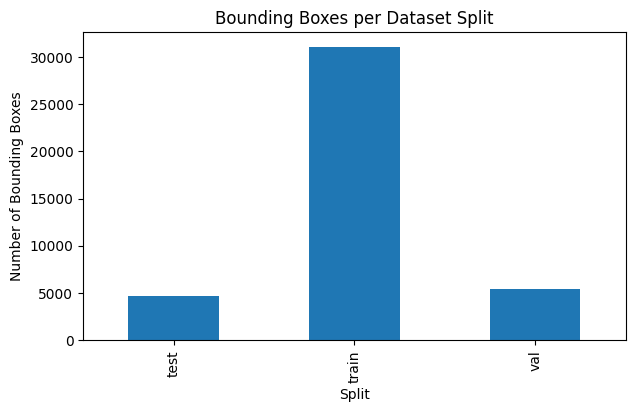

In [6]:
split_summary["boxes"].plot(kind="bar", figsize=(7, 4))

plt.title("Bounding Boxes per Dataset Split")
plt.xlabel("Split")
plt.ylabel("Number of Bounding Boxes")
plt.show()

The train split contains the largest number of annotations, while validation and test are smaller. This is expected because the training set needs the most data for model learning.

## Species Distribution

In [7]:
species_counts = (
    df["class_name"]
    .value_counts()
    .sort_values(ascending=False)
)

display(species_counts)

class_name
Wild boar      16231
Red deer       14121
Roe deer        5445
Fallow deer     4280
Hybrid Pig      1045
Name: count, dtype: int64

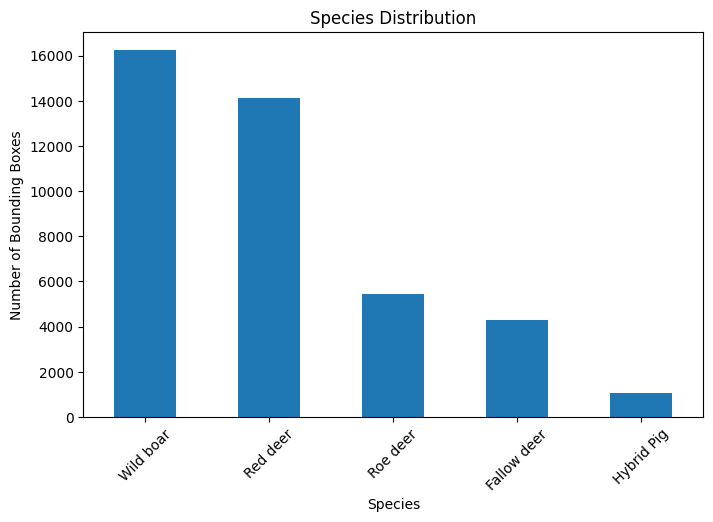

In [8]:
species_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Bounding Boxes")
plt.xticks(rotation=45)
plt.show()

The species distribution is imbalanced. Some species occur much more often than others, which can make classification harder for underrepresented species.

This is especially relevant for the later species-classification part of the project.

## Species Percentage

In [9]:
species_percentages = (
    species_counts / species_counts.sum() * 100
).round(2)

display(species_percentages)

class_name
Wild boar      39.47
Red deer       34.34
Roe deer       13.24
Fallow deer    10.41
Hybrid Pig      2.54
Name: count, dtype: float64

The percentage table shows the relative share of each species in the dataset. This makes the class imbalance easier to interpret than raw counts alone.

## Bounding Box Area Distribution

In [10]:
display(df["area"].describe())

count    41122.000000
mean         0.001753
std          0.003836
min          0.000021
25%          0.001153
50%          0.001579
75%          0.002083
max          0.265732
Name: area, dtype: float64

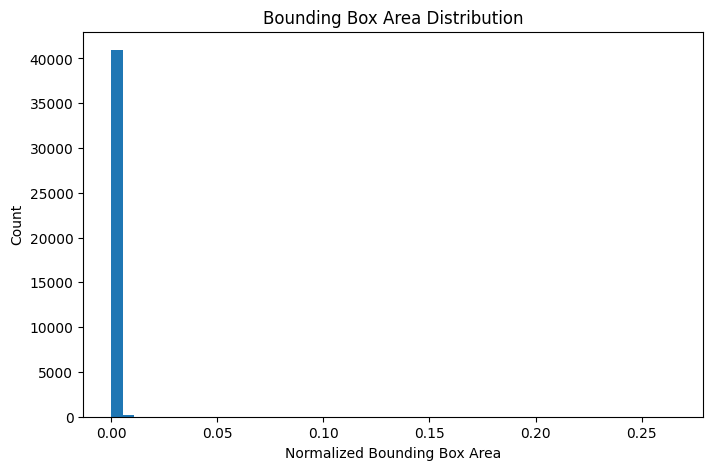

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["area"], bins=50)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Count")
plt.show()

Most bounding boxes are very small relative to the full image. This means many animals appear far away or occupy only a small region of the thermal image, making detection more difficult.

## Animals per Image

In [12]:
objects_per_image = df.groupby("image_id").size()

display(objects_per_image.describe())

count    18139.000000
mean         2.267049
std          2.499558
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         40.000000
dtype: float64

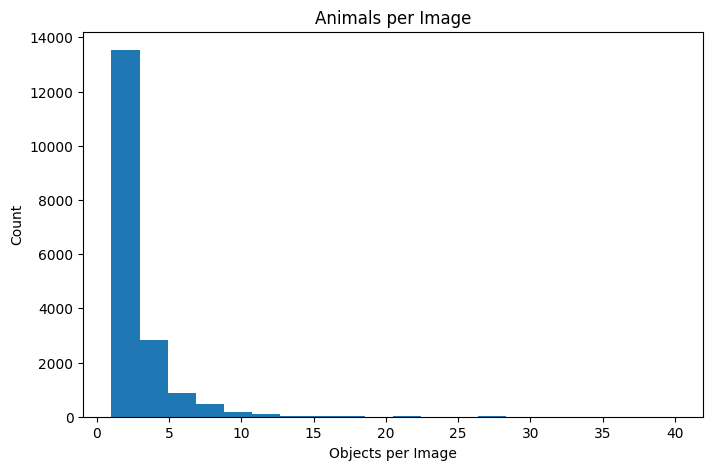

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(objects_per_image, bins=20)

plt.title("Animals per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Count")
plt.show()

Most images contain only a few animals, but some images contain many animals. This means the dataset includes both simple and crowded detection scenarios.

## Class Imbalance Ratio

In [16]:
species_counts.max() / species_counts.min()

np.float64(15.532057416267943)

The most common species appears approximately 15.53 times more frequently than the least common species, indicating a high class imbalance that may influence classification performance.

## Key Findings

- The original filtered annotations contain five species classes.
- The dataset is class-imbalanced, which can affect later species classification.
- Most animals are small in the image, making object detection challenging.
- Some images contain multiple animals, so the detector must handle crowded scenes.
- For YOLO detection training, the labels are later converted into one class: `Animal`.

In total:
- 41,122 bounding boxes
- 18,139 images
- Wild boar is most common
- Hybrid Pig is least common
- imbalance ratio ≈ 15.53